# Prompt Selection and Subset Evaluation
This script selects the optimal prompt by comparing Sharpe ratios across multiple fixed-size subsets evaluated under identical data conditions.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. News Headlines Data Cleaning (Deduplicate)

In [24]:
df_news = pd.read_csv("train_df.csv")
df_news

,ticker,date,title,content,link,symbols,tags
0,ACCO,2021-06-29T13:00:00+00:00,PowerA Announces the New Designed for Xbox Spe...,The One-of-a-Kind Designed for Xbox Controller...,https://finance.yahoo.com/news/powera-announce...,['ACCO.US'],"['GAMING ACCESSORIES', 'GAMING EXPERIENCE', 'P..."
1,ACCO,2021-06-29T13:00:00+00:00,PowerA Announces the New Designed for Xbox Spe...,The One-of-a-Kind Designed for Xbox Controller...,https://finance.yahoo.com/news/powera-announce...,['ACCO.US'],"['GAMING ACCESSORIES', 'GAMING EXPERIENCE', 'P..."
2,ACCO,2021-06-24T12:00:00+00:00,ACCO Brands Corporation Announces Participatio...,"LAKE ZURICH, Ill., June 24, 2021--(BUSINESS WI...",https://finance.yahoo.com/news/acco-brands-cor...,['ACCO.US'],"['ACCO BRANDS', 'ACCO BRANDS CORPORATION', 'NY..."
3,ACCO,2021-06-24T12:00:00+00:00,ACCO Brands Corporation Announces Participatio...,"LAKE ZURICH, Ill., June 24, 2021--(BUSINESS WI...",https://finance.yahoo.com/news/acco-brands-cor...,['ACCO.US'],"['ACCO BRANDS', 'ACCO BRANDS CORPORATION', 'NY..."
4,ACCO,2021-06-16T12:00:00+00:00,Derwent® Launches New Chromaflow Colour Pencil...,Chromaflow pencils have been formulated with r...,https://finance.yahoo.com/news/derwent-launche...,['ACCO.US'],"['BLICK ART MATERIALS', 'CHROMAFLOW COLOUR PEN..."
...,...,...,...,...,...,...,...
13565,XYL,2020-12-07T13:47:27+00:00,Why Xylem Inc. (NYSE:XYL) Could Be Worth Watching,Let's talk about the popular Xylem Inc. (NYSE:...,https://finance.yahoo.com/news/why-xylem-inc-n...,['XYL.US'],"['SHARE PRICE', 'SUBSTANTIAL PRICE', 'XYL', 'X..."
13566,XYL,2020-10-30T18:44:36+00:00,Income Investors Should Know That Xylem Inc. (...,Regular readers will know that we love our div...,https://finance.yahoo.com/news/income-investor...,['XYL.US'],"['EARNINGS PER SHARE', 'PAYOUT RATIO', 'XYLEM'..."
13567,XYL,2020-10-29T16:08:04+00:00,"Xylem (XYL) Q3 Earnings Top Estimates, Q4 Orga...",Xylem Inc. XYL reported impressive results for...,https://finance.yahoo.com/news/xylem-xyl-q3-ea...,"['AIMC.US', 'XYL.US']","['ORGANIC SALES', 'REPORTED QUARTER', 'WATER I..."
13568,XYL,2020-06-25T00:00:00+00:00,4 Stocks to Buy to Protect Your Portfolio From...,As you think about buying batteries and flashl...,https://investorplace.com/2020/06/4-stocks-to-...,"['AIZ.US', 'XYL.US']",[]


In [25]:
df_news['date'] = pd.to_datetime(df_news['date'])
df_news = df_news.sort_values(by='date')
df_news

,ticker,date,title,content,link,symbols,tags
5713,EGBN,2020-01-02 11:00:00+00:00,Eagle Bancorp Announces Earnings Call On Janua...,"BETHESDA, Md., Jan. 02, 2020 (GLOBE NEWSWIRE...",https://www.globenewswire.com/news-release/202...,['EGBN.US'],"['BANKING', 'CONFERENCE CALL', 'CORPORATE', 'E..."
11674,TFX,2020-01-02 11:45:00+00:00,Teleflex to Present at the 38th Annual J.P. Mo...,"WAYNE, Pa., Jan. 02, 2020 (GLOBE NEWSWIRE) -...",https://www.globenewswire.com/news-release/202...,['TFX.US'],"['HEALTHCARE', 'MEDICAL DEVICES', 'NYSE:TFX', ..."
5802,ESE,2020-01-02 11:45:00+00:00,Sonoco Acquires Healthcare Packaging and Medic...,"HARTSVILLE, S.C., Jan. 02, 2020 (GLOBE NEWSW...",https://www.globenewswire.com/news-release/202...,"['ESE.US', 'SON.US']","['NYSE:SON', 'SONOCO PRODUCTS COMPANY']"
12066,VECO,2020-01-02 13:10:00+00:00,Veeco Appoints John P. Kiernan Senior Vice Pre...,"PLAINVIEW, N.Y., Jan. 02, 2020 (GLOBE NEWSWI...",https://www.globenewswire.com/news-release/202...,['VECO.US'],"['CFO', 'NASDAQ:VECO', 'VEECO', 'VEECO INSTRUM..."
10774,SGC,2020-01-02 13:41:00+00:00,Superior Group of Companies™ Names James Shimi...,"SEMINOLE, Fla., Jan. 02, 2020 (GLOBE NEWSWIR...",https://www.globenewswire.com/news-release/202...,['SGC.US'],"['INC', 'NASDAQ:SGC', 'SUPERIOR GROUP OF COMPA..."
...,...,...,...,...,...,...,...
2460,CVX,2021-06-30 22:00:00+00:00,The Best Energy Dividend Stocks Of 2021,As OPEC+ gets ready for its next meeting to di...,https://finance.yahoo.com/news/best-energy-div...,"['CVX.US', 'CWEN-A.US', 'CWEN.US', 'EPD.US', '...","['CLEARWAY ENERGY', 'DIAMONDBACK ENERGY', 'DIV..."
10090,REKR,2021-06-30 22:15:00+00:00,"CLASS ACTION UPDATE for WISH, RLX and REKR: Le...","NEW YORK, NY / ACCESSWIRE / June 30, 2021 / Le...",https://finance.yahoo.com/news/class-action-wi...,"['REKR.US', 'RLX.US', 'WISH.US']","['CLASS ACTION LAWSUITS', 'INITIAL PUBLIC STOC..."
10089,REKR,2021-06-30 22:15:00+00:00,"CLASS ACTION UPDATE for WISH, RLX and REKR: Le...","NEW YORK, NY / ACCESSWIRE / June 30, 2021 / Le...",https://finance.yahoo.com/news/class-action-wi...,"['REKR.US', 'RLX.US', 'WISH.US']","['CLASS ACTION LAWSUITS', 'INITIAL PUBLIC STOC..."
12371,WMT,2021-06-30 23:42:35+00:00,Walmart de Mexico to allow older grocery packe...,By Daina Beth Solomon\n\nMEXICO CITY (Reuters)...,https://ca.finance.yahoo.com/news/walmart-mexi...,"['WALM34.SA', 'WMT.US']","['ANDRES MANUEL LOPEZ OBRADOR', 'MEXICO', 'OLD..."


In [26]:
df_news.isna().sum()

ticker     0
date       0
title      0
content    0
link       0
symbols    0
tags       0
dtype: int64

In [27]:
(df_news.iloc[0] == df_news.iloc[1]) # These two news have some every thing, just the link is different!!!!

ticker     False
date       False
title      False
content    False
link       False
symbols    False
tags       False
dtype: bool

In [28]:
df_news.iloc[0].link

'https://www.globenewswire.com/news-release/2020/01/02/1965585/11376/en/Eagle-Bancorp-Announces-Earnings-Call-On-January-16-2020.html'

In [29]:
df_news.iloc[1].link 

'https://www.globenewswire.com/news-release/2020/01/02/1965611/0/en/Teleflex-to-Present-at-the-38th-Annual-J-P-Morgan-Healthcare-Conference.html'

In [30]:
df_news.iloc[0] # Same news, only difference is the ".tsrc=rss" in the URL link -> Still leads to the same news website: Duplicate!!!

ticker                                                  EGBN
date                               2020-01-02 11:00:00+00:00
title      Eagle Bancorp Announces Earnings Call On Janua...
content    BETHESDA, Md., Jan.  02, 2020  (GLOBE NEWSWIRE...
link       https://www.globenewswire.com/news-release/202...
symbols                                          ['EGBN.US']
tags       ['BANKING', 'CONFERENCE CALL', 'CORPORATE', 'E...
Name: 5713, dtype: object

In [31]:
df_news.iloc[1]

ticker                                                   TFX
date                               2020-01-02 11:45:00+00:00
title      Teleflex to Present at the 38th Annual J.P. Mo...
content    WAYNE, Pa., Jan.  02, 2020  (GLOBE NEWSWIRE) -...
link       https://www.globenewswire.com/news-release/202...
symbols                                           ['TFX.US']
tags       ['HEALTHCARE', 'MEDICAL DEVICES', 'NYSE:TFX', ...
Name: 11674, dtype: object

In [32]:
# Generate "news_id" based on columns "ticker", "date", "title", "content" and delete the duplicates
cols = ["ticker", "date", "title", "content"]
df_news = df_news.drop_duplicates(subset=cols, keep="first")
df_news["news_id"] = range(1, len(df_news) + 1)
df_news

C:\Users\zhaok\AppData\Local\Temp\ipykernel_2468\3901786885.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news["news_id"] = range(1, len(df_news) + 1)


,ticker,date,title,content,link,symbols,tags,news_id
5713,EGBN,2020-01-02 11:00:00+00:00,Eagle Bancorp Announces Earnings Call On Janua...,"BETHESDA, Md., Jan. 02, 2020 (GLOBE NEWSWIRE...",https://www.globenewswire.com/news-release/202...,['EGBN.US'],"['BANKING', 'CONFERENCE CALL', 'CORPORATE', 'E...",1
11674,TFX,2020-01-02 11:45:00+00:00,Teleflex to Present at the 38th Annual J.P. Mo...,"WAYNE, Pa., Jan. 02, 2020 (GLOBE NEWSWIRE) -...",https://www.globenewswire.com/news-release/202...,['TFX.US'],"['HEALTHCARE', 'MEDICAL DEVICES', 'NYSE:TFX', ...",2
5802,ESE,2020-01-02 11:45:00+00:00,Sonoco Acquires Healthcare Packaging and Medic...,"HARTSVILLE, S.C., Jan. 02, 2020 (GLOBE NEWSW...",https://www.globenewswire.com/news-release/202...,"['ESE.US', 'SON.US']","['NYSE:SON', 'SONOCO PRODUCTS COMPANY']",3
12066,VECO,2020-01-02 13:10:00+00:00,Veeco Appoints John P. Kiernan Senior Vice Pre...,"PLAINVIEW, N.Y., Jan. 02, 2020 (GLOBE NEWSWI...",https://www.globenewswire.com/news-release/202...,['VECO.US'],"['CFO', 'NASDAQ:VECO', 'VEECO', 'VEECO INSTRUM...",4
10774,SGC,2020-01-02 13:41:00+00:00,Superior Group of Companies™ Names James Shimi...,"SEMINOLE, Fla., Jan. 02, 2020 (GLOBE NEWSWIR...",https://www.globenewswire.com/news-release/202...,['SGC.US'],"['INC', 'NASDAQ:SGC', 'SUPERIOR GROUP OF COMPA...",5
...,...,...,...,...,...,...,...,...
10091,REKR,2021-06-30 21:46:00+00:00,SHAREHOLDER ALERT: ATER RLX REKR: The Law Offi...,"NEW YORK, NY / ACCESSWIRE / June 30, 2021 / Th...",https://finance.yahoo.com/news/shareholder-ale...,"['ATER.US', 'REKR.US', 'RLX.US']","['ATERIAN', 'INC', 'LAW OFFICES', 'RLX', 'VINC...",10820
7785,LRCX,2021-06-30 21:53:02+00:00,Dow Jones Futures: Apple Tests Buy Point In Ma...,The market rally remains healthy with Apple fl...,https://finance.yahoo.com/m/b127c71f-0779-38c6...,"['AAPL.US', 'AAPL34.SA', 'AMAT.US', 'COMP.US',...","['AMAT STOCK', 'APPLE', 'DOW FUTURES', 'DOW JO...",10821
2460,CVX,2021-06-30 22:00:00+00:00,The Best Energy Dividend Stocks Of 2021,As OPEC+ gets ready for its next meeting to di...,https://finance.yahoo.com/news/best-energy-div...,"['CVX.US', 'CWEN-A.US', 'CWEN.US', 'EPD.US', '...","['CLEARWAY ENERGY', 'DIAMONDBACK ENERGY', 'DIV...",10822
10090,REKR,2021-06-30 22:15:00+00:00,"CLASS ACTION UPDATE for WISH, RLX and REKR: Le...","NEW YORK, NY / ACCESSWIRE / June 30, 2021 / Le...",https://finance.yahoo.com/news/class-action-wi...,"['REKR.US', 'RLX.US', 'WISH.US']","['CLASS ACTION LAWSUITS', 'INITIAL PUBLIC STOC...",10823


In [34]:
df_news.to_csv("News_headlines_cleaned.csv", index=False)

## 2. Split the cleaned news headline data into different subsets considering token economics

In [15]:
df_news_cleaned = pd.read_csv("News_headlines_cleaned.csv")
df_news_cleaned

,ticker,date,title,content,link,symbols,tags,news_id,datetime_utc,datetime_est,hour,minute,news_type
0,ACCO,2021-06-29T13:00:00+00:00,PowerA Announces the New Designed for Xbox Spe...,The One-of-a-Kind Designed for Xbox Controller...,https://finance.yahoo.com/news/powera-announce...,['ACCO.US'],"['GAMING ACCESSORIES', 'GAMING EXPERIENCE', 'P...",1,2021-06-29 13:00:00+00:00,2021-06-29 09:00:00-04:00,9,0,overnight
1,ACCO,2021-06-24T12:00:00+00:00,ACCO Brands Corporation Announces Participatio...,"LAKE ZURICH, Ill., June 24, 2021--(BUSINESS WI...",https://finance.yahoo.com/news/acco-brands-cor...,['ACCO.US'],"['ACCO BRANDS', 'ACCO BRANDS CORPORATION', 'NY...",2,2021-06-24 12:00:00+00:00,2021-06-24 08:00:00-04:00,8,0,overnight
2,ACCO,2021-06-16T12:00:00+00:00,Derwent® Launches New Chromaflow Colour Pencil...,Chromaflow pencils have been formulated with r...,https://finance.yahoo.com/news/derwent-launche...,['ACCO.US'],"['BLICK ART MATERIALS', 'CHROMAFLOW COLOUR PEN...",3,2021-06-16 12:00:00+00:00,2021-06-16 08:00:00-04:00,8,0,overnight
3,ACCO,2021-06-10T16:00:04+00:00,All You Need to Know About Acco (ACCO) Rating ...,Acco Brands (ACCO) could be a solid choice for...,https://finance.yahoo.com/news/know-acco-acco-...,['ACCO.US'],"['ACCO BRANDS', 'CONSENSUS ESTIMATE', 'EARNING...",4,2021-06-10 16:00:04+00:00,2021-06-10 12:00:04-04:00,12,0,intraday
4,ACCO,2021-06-09T20:30:00+00:00,ACCO Brands Corporation Announces Participatio...,ACCO Brands Corporation (NYSE: ACCO) today ann...,https://finance.yahoo.com/news/acco-brands-cor...,['ACCO.US'],"['ACCO BRANDS', 'NYSE']",5,2021-06-09 20:30:00+00:00,2021-06-09 16:30:00-04:00,16,30,overnight
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10819,XYL,2020-12-07T13:47:27+00:00,Why Xylem Inc. (NYSE:XYL) Could Be Worth Watching,Let's talk about the popular Xylem Inc. (NYSE:...,https://finance.yahoo.com/news/why-xylem-inc-n...,['XYL.US'],"['SHARE PRICE', 'SUBSTANTIAL PRICE', 'XYL', 'X...",10820,2020-12-07 13:47:27+00:00,2020-12-07 08:47:27-05:00,8,47,overnight
10820,XYL,2020-10-30T18:44:36+00:00,Income Investors Should Know That Xylem Inc. (...,Regular readers will know that we love our div...,https://finance.yahoo.com/news/income-investor...,['XYL.US'],"['EARNINGS PER SHARE', 'PAYOUT RATIO', 'XYLEM'...",10821,2020-10-30 18:44:36+00:00,2020-10-30 14:44:36-04:00,14,44,intraday
10821,XYL,2020-10-29T16:08:04+00:00,"Xylem (XYL) Q3 Earnings Top Estimates, Q4 Orga...",Xylem Inc. XYL reported impressive results for...,https://finance.yahoo.com/news/xylem-xyl-q3-ea...,"['AIMC.US', 'XYL.US']","['ORGANIC SALES', 'REPORTED QUARTER', 'WATER I...",10822,2020-10-29 16:08:04+00:00,2020-10-29 12:08:04-04:00,12,8,intraday
10822,XYL,2020-06-25T00:00:00+00:00,4 Stocks to Buy to Protect Your Portfolio From...,As you think about buying batteries and flashl...,https://investorplace.com/2020/06/4-stocks-to-...,"['AIZ.US', 'XYL.US']",[],10823,2020-06-25 00:00:00+00:00,2020-06-24 20:00:00-04:00,20,0,overnight


In [18]:
df_news_cleaned['date'] = pd.to_datetime(df_news_cleaned['date'])
df_news_cleaned = df_news_cleaned.sort_values(by='date')
df_news_cleaned

,ticker,date,title,content,link,symbols,tags,news_id,datetime_utc,datetime_est,hour,minute,news_type
4606,EGBN,2020-01-02 11:00:00+00:00,Eagle Bancorp Announces Earnings Call On Janua...,"BETHESDA, Md., Jan. 02, 2020 (GLOBE NEWSWIRE...",https://www.globenewswire.com/news-release/202...,['EGBN.US'],"['BANKING', 'CONFERENCE CALL', 'CORPORATE', 'E...",4607,2020-01-02 11:00:00+00:00,2020-01-02 06:00:00-05:00,6,0,overnight
4671,ESE,2020-01-02 11:45:00+00:00,Sonoco Acquires Healthcare Packaging and Medic...,"HARTSVILLE, S.C., Jan. 02, 2020 (GLOBE NEWSW...",https://www.globenewswire.com/news-release/202...,"['ESE.US', 'SON.US']","['NYSE:SON', 'SONOCO PRODUCTS COMPANY']",4672,2020-01-02 11:45:00+00:00,2020-01-02 06:45:00-05:00,6,45,overnight
9342,TFX,2020-01-02 11:45:00+00:00,Teleflex to Present at the 38th Annual J.P. Mo...,"WAYNE, Pa., Jan. 02, 2020 (GLOBE NEWSWIRE) -...",https://www.globenewswire.com/news-release/202...,['TFX.US'],"['HEALTHCARE', 'MEDICAL DEVICES', 'NYSE:TFX', ...",9343,2020-01-02 11:45:00+00:00,2020-01-02 06:45:00-05:00,6,45,overnight
9607,VECO,2020-01-02 13:10:00+00:00,Veeco Appoints John P. Kiernan Senior Vice Pre...,"PLAINVIEW, N.Y., Jan. 02, 2020 (GLOBE NEWSWI...",https://www.globenewswire.com/news-release/202...,['VECO.US'],"['CFO', 'NASDAQ:VECO', 'VEECO', 'VEECO INSTRUM...",9608,2020-01-02 13:10:00+00:00,2020-01-02 08:10:00-05:00,8,10,overnight
8619,SGC,2020-01-02 13:41:00+00:00,Superior Group of Companies™ Names James Shimi...,"SEMINOLE, Fla., Jan. 02, 2020 (GLOBE NEWSWIR...",https://www.globenewswire.com/news-release/202...,['SGC.US'],"['INC', 'NASDAQ:SGC', 'SUPERIOR GROUP OF COMPA...",8620,2020-01-02 13:41:00+00:00,2020-01-02 08:41:00-05:00,8,41,overnight
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8074,REKR,2021-06-30 21:46:00+00:00,SHAREHOLDER ALERT: ATER RLX REKR: The Law Offi...,"NEW YORK, NY / ACCESSWIRE / June 30, 2021 / Th...",https://finance.yahoo.com/news/shareholder-ale...,"['ATER.US', 'REKR.US', 'RLX.US']","['ATERIAN', 'INC', 'LAW OFFICES', 'RLX', 'VINC...",8075,2021-06-30 21:46:00+00:00,2021-06-30 17:46:00-04:00,17,46,overnight
6180,LRCX,2021-06-30 21:53:02+00:00,Dow Jones Futures: Apple Tests Buy Point In Ma...,The market rally remains healthy with Apple fl...,https://finance.yahoo.com/m/b127c71f-0779-38c6...,"['AAPL.US', 'AAPL34.SA', 'AMAT.US', 'COMP.US',...","['AMAT STOCK', 'APPLE', 'DOW FUTURES', 'DOW JO...",6181,2021-06-30 21:53:02+00:00,2021-06-30 17:53:02-04:00,17,53,overnight
1864,CVX,2021-06-30 22:00:00+00:00,The Best Energy Dividend Stocks Of 2021,As OPEC+ gets ready for its next meeting to di...,https://finance.yahoo.com/news/best-energy-div...,"['CVX.US', 'CWEN-A.US', 'CWEN.US', 'EPD.US', '...","['CLEARWAY ENERGY', 'DIAMONDBACK ENERGY', 'DIV...",1865,2021-06-30 22:00:00+00:00,2021-06-30 18:00:00-04:00,18,0,overnight
8073,REKR,2021-06-30 22:15:00+00:00,"CLASS ACTION UPDATE for WISH, RLX and REKR: Le...","NEW YORK, NY / ACCESSWIRE / June 30, 2021 / Le...",https://finance.yahoo.com/news/class-action-wi...,"['REKR.US', 'RLX.US', 'WISH.US']","['CLASS ACTION LAWSUITS', 'INITIAL PUBLIC STOC...",8074,2021-06-30 22:15:00+00:00,2021-06-30 18:15:00-04:00,18,15,overnight


In [19]:
monthly_counts = (
    df_news_cleaned
    .groupby(df_news_cleaned['date'].dt.to_period('M'))
    .size()
)

monthly_counts

C:\Users\zhaok\AppData\Local\Temp\ipykernel_2468\1720727713.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(df_news_cleaned['date'].dt.to_period('M'))


date
2020-01      73
2020-02      80
2020-03      61
2020-04     131
2020-05     125
2020-06     144
2020-07     143
2020-08     186
2020-09     227
2020-10     273
2020-11     276
2020-12     546
2021-01     516
2021-02     923
2021-03    1639
2021-04    2052
2021-05    1745
2021-06    1684
Freq: M, dtype: int64

In [20]:
print("Mean:", monthly_counts.mean())
print("Std:", monthly_counts.std())
print("Min:", monthly_counts.min())
print("Max:", monthly_counts.max())
print("Coefficient of Variation (std/mean):", monthly_counts.std() / monthly_counts.mean())

Mean: 601.3333333333334
Std: 686.4926202422417
Min: 61
Max: 2052
Coefficient of Variation (std/mean): 1.1416174394272312


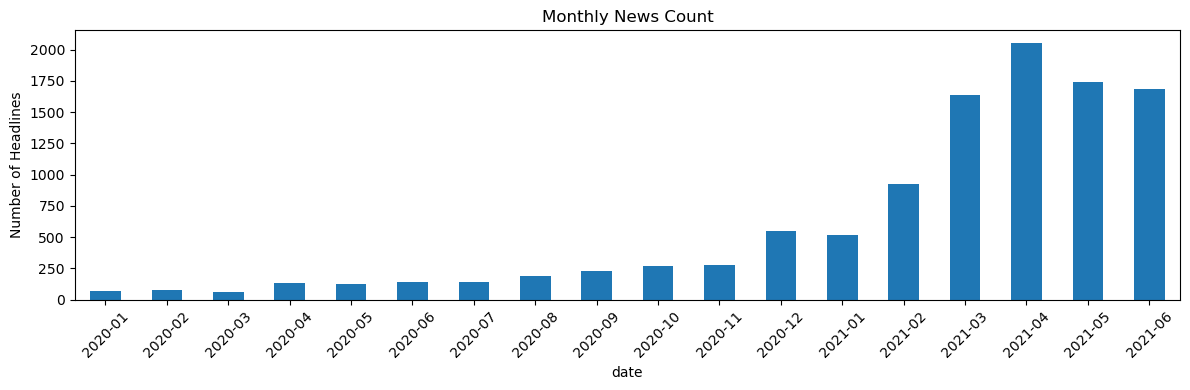

In [22]:
# Temporal Distribution of News Headlines
monthly_counts.plot(kind='bar', figsize=(12,4))
plt.title("Monthly News Count")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Figures/monthly_news_count.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [18]:
df_news_cleaned["date"] = pd.to_datetime(df_news_cleaned["date"], errors="coerce")
df_news_cleaned["year"] = df_news_cleaned["date"].dt.year
df_news_cleaned["month"] = df_news_cleaned["date"].dt.to_period("M")

C:\Users\zhaok\AppData\Local\Temp\ipykernel_19244\4286011129.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_news_cleaned["month"] = df_news_cleaned["date"].dt.to_period("M")


In [ ]:
# one_tenth_news_subset
one_tenth_news_subset = df_news_cleaned.groupby("month", group_keys=False)\
                  .apply(lambda x: x.sample(frac=0.1, random_state=1))

In [ ]:
one_tenth_news_subset.to_csv("one_tenth_news_subset.csv", index=False)

In [ ]:
# one_fifth_news_subset
one_fifth_news_subset_1 = df_news_cleaned.groupby("month", group_keys=False)\
                    .apply(lambda x: x.sample(frac=0.2, random_state=2))
one_fifth_news_subset_2 = df_news_cleaned.groupby("month", group_keys=False)\
                    .apply(lambda x: x.sample(frac=0.2, random_state=3))

In [ ]:
one_fifth_news_subset_1.to_csv("one_fifth_news_subset_1.csv", index=False)
one_fifth_news_subset_2.to_csv("one_fifth_news_subset_2.csv", index=False)

In [ ]:
# half_news_subset
half_news_subset_1 = df_news_cleaned.groupby("month", group_keys=False)\
                    .apply(lambda x: x.sample(frac=0.5, random_state=4))
halfset1_indices = half_news_subset_1.index
half_news_subset_2 = df_news_cleaned.drop(halfset1_indices)

In [ ]:
half_news_subset_1.to_csv("half_news_subset_1.csv", index=False)
half_news_subset_2.to_csv("half_news_subset_2.csv", index=False)

## 3. Aggregate the daily output to montly level for each company

In [2]:
# Read the sentiment result from the training set of Original Prompt (Benchmark Prompt)

# --> Change the file for any other sentiment output to calculate the sharpe ratio (one fifth, half news, merge half 1 + 2)
output_op = pd.read_csv("output_op_combined.csv")
output_op

,ticker,date,title,content,link,symbols,tags,news_id,datetime_utc,datetime_est,hour,minute,news_type,year,month,sentiment
0,EBMT,2020-01-28 17:00:00+00:00,"Eagle Bancorp Montana Earns $2.3 Million, or $...","HELENA, Mont., Jan. 28, 2020 (GLOBE NEWSWIRE...",https://www.globenewswire.com/news-release/202...,['EBMT.US'],"['EAGLE BANCORP MONTANA', 'INC', 'NASDAQ:EBMT']",4432,2020-01-28 17:00:00+00:00,2020-01-28 12:00:00-05:00,12,0,intraday,2020,2020-01,1
1,PFBC,2020-01-22 21:30:00+00:00,Preferred Bank Reports 2019 Fourth Quarter and...,"LOS ANGELES, Jan. 22, 2020 (GLOBE NEWSWIRE) ...",https://www.globenewswire.com/news-release/202...,['PFBC.US'],"['NASDAQ:PFBC', 'PREFERRED BANK']",7193,2020-01-22 21:30:00+00:00,2020-01-22 16:30:00-05:00,16,30,overnight,2020,2020-01,0
2,BLNK,2020-01-30 14:15:00+00:00,Blink Charging Announces the Appointment of Th...,"Miami Beach, FL, Jan. 30, 2020 (GLOBE NEWSWI...",https://www.globenewswire.com/news-release/202...,"['BLNK.US', 'BLNKW.US']","['BLINK CHARGING CO', 'BLNK', 'BLNKW', 'ELECTR...",1404,2020-01-30 14:15:00+00:00,2020-01-30 09:15:00-05:00,9,15,overnight,2020,2020-01,1
3,VECO,2020-01-02 13:10:00+00:00,Veeco Appoints John P. Kiernan Senior Vice Pre...,"PLAINVIEW, N.Y., Jan. 02, 2020 (GLOBE NEWSWI...",https://www.globenewswire.com/news-release/202...,['VECO.US'],"['CFO', 'NASDAQ:VECO', 'VEECO', 'VEECO INSTRUM...",9608,2020-01-02 13:10:00+00:00,2020-01-02 08:10:00-05:00,8,10,overnight,2020,2020-01,0
4,PAVM,2020-01-13 14:30:00+00:00,PAVmed Receives Formal Notification of Nasdaq ...,"NEW YORK, Jan. 13, 2020 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/202...,"['PAVM.US', 'PAVMZ.US']","['CARPX™', 'DISAPPEAR™', 'ESOGUARD™/ESOCHECK™'...",7115,2020-01-13 14:30:00+00:00,2020-01-13 09:30:00-05:00,9,30,intraday,2020,2020-01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10819,DRI,2021-06-24 20:00:12+00:00,Darden Restaurants Inc (DRI) Q4 2021 Earnings ...,DRI earnings call for the period ending May 30...,https://finance.yahoo.com/m/322222ca-7a4f-3a99...,['DRI.US'],[],4100,2021-06-24 20:00:12+00:00,2021-06-24 16:00:12-04:00,16,0,intraday,2021,2021-06,0
10820,DIS,2021-06-04 17:04:26+00:00,Roku Wants to Dominate the Media Landscape,"Despite falling 33% since its all time high, R...",https://finance.yahoo.com/news/roku-wants-domi...,"['AAPL.US', 'AMZN.US', 'CMCSA.US', 'DIS.US', '...","['MARKET CAP', 'ROKU', 'ROKU STOCK']",3143,2021-06-04 17:04:26+00:00,2021-06-04 13:04:26-04:00,13,4,intraday,2021,2021-06,0
10821,MRK,2021-06-21 18:44:01+00:00,Delta COVID-19 variant likely to become domina...,"Dr. Susannah Hills, Pediatric Airway surgeon a...",https://finance.yahoo.com/video/delta-covid-19...,"['AZN.US', 'AZNCF.US', 'BKEAF.US', 'BNTX.US', ...","['ASSISTANT PROFESSOR', 'SUSANNAH HILLS']",6560,2021-06-21 18:44:01+00:00,2021-06-21 14:44:01-04:00,14,44,intraday,2021,2021-06,0
10822,TSE,2021-06-10 21:20:58+00:00,10 Best Plastics Stocks to Buy Now,In this article we will take a look at the 10 ...,https://finance.yahoo.com/news/10-best-plastic...,"['AMCR.US', 'ATR.US', 'BERY.US', 'DD.US', 'GT....","['APTARGROUP', 'BERRY GLOBAL', 'EXXON MOBIL CO...",9431,2021-06-10 21:20:58+00:00,2021-06-10 17:20:58-04:00,17,20,overnight,2021,2021-06,1


In [3]:
# Benchmark Prompt: Take average of all the daily news' gpt-scores on monthly level for each company(ticker)
output_op["month"] = pd.to_datetime(output_op["date"]).dt.to_period("M")
gpt_month_op = output_op.groupby(["ticker", "month"])["sentiment"].mean().reset_index()
gpt_month_op.rename(columns={"sentiment": "GPT_score_month"}, inplace=True)
gpt_month_op

C:\Users\yesem\AppData\Local\Temp\ipykernel_10012\3959259139.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  output_op["month"] = pd.to_datetime(output_op["date"]).dt.to_period("M")


,ticker,month,GPT_score_month
0,ACCO,2020-06,0.000000
1,ACCO,2020-09,0.000000
2,ACCO,2020-11,0.000000
3,ACCO,2020-12,0.000000
4,ACCO,2021-01,0.000000
...,...,...,...
968,XYL,2021-01,0.000000
969,XYL,2021-02,0.500000
970,XYL,2021-04,0.333333
971,XYL,2021-05,0.388889


## 4. Merge the output with return data through ticker and date

In [4]:
# Montly return data
df_return = pd.read_csv("train_return_data.csv")
df_return.head(40)

,date,TICKER,PRC,RET,SHROUT,MV_USD,MV_USD_lag
0,1985-12-31,NaN,NaN,NaN,NaN,0.00000,NaN
1,1986-01-31,OMFGA,-4.37500,NaN,3680.0,16100.00000,NaN
2,1986-02-28,OMFGA,-3.25000,-0.257143,3680.0,11960.00000,16100.00000
3,1986-03-31,OMFGA,-4.43750,0.365385,3680.0,16330.00000,11960.00000
4,1986-04-30,OMFGA,-4.00000,-0.098592,3793.0,15172.00000,16330.00000
5,1986-05-30,OMFGA,-3.10938,-0.222656,3793.0,11793.87834,15172.00000
6,1986-06-30,OMFGA,-3.09375,-0.005025,3793.0,11734.59375,11793.87834
7,1986-07-31,OMFGA,-2.84375,-0.080808,3793.0,10786.34375,11734.59375
8,1986-08-29,OMFGA,-1.09375,-0.615385,3793.0,4148.59375,10786.34375
9,1986-09-30,OMFGA,-1.03125,-0.057143,3793.0,3911.53125,4148.59375


In [5]:
df_return = df_return.rename(columns={"TICKER": "ticker"})
df_return["month"] = pd.to_datetime(df_return["date"]).dt.to_period("M")

In [6]:
# Merge stock return data with the sentimal result of orginal prompt (benmark prompt)
df_merged_op = df_return.merge(gpt_month_op, on=["ticker", "month"], how="left")
df_merged_op

,date,ticker,PRC,RET,SHROUT,MV_USD,MV_USD_lag,month,GPT_score_month
0,1985-12-31,NaN,NaN,NaN,NaN,0.000000e+00,NaN,1985-12,NaN
1,1986-01-31,OMFGA,-4.37500,NaN,3680.0,1.610000e+04,NaN,1986-01,NaN
2,1986-02-28,OMFGA,-3.25000,-0.257143,3680.0,1.196000e+04,1.610000e+04,1986-02,NaN
3,1986-03-31,OMFGA,-4.43750,0.365385,3680.0,1.633000e+04,1.196000e+04,1986-03,NaN
4,1986-04-30,OMFGA,-4.00000,-0.098592,3793.0,1.517200e+04,1.633000e+04,1986-04,NaN
...,...,...,...,...,...,...,...,...,...
5101000,2023-08-31,TSLA,258.07999,-0.034962,3173994.0,8.191443e+08,8.488212e+08,2023-08,NaN
5101001,2023-09-29,TSLA,250.22000,-0.030456,3179000.0,7.954494e+08,8.191443e+08,2023-09,NaN
5101002,2023-10-31,TSLA,200.84000,-0.197346,3178921.0,6.384545e+08,7.954494e+08,2023-10,NaN
5101003,2023-11-30,TSLA,240.08000,0.195379,3178921.0,7.631954e+08,6.384545e+08,2023-11,NaN


## 5. Bild the long-short portfolio and calculate portfolio return

In [7]:
# Use the monthly GPT sentiment score as the trading signal
df_merged_op["signal"] = df_merged_op["GPT_score_month"]

# Shift the returns to get the return of the next month (t+1) for each stock
df_merged_op['RET_t_plus_1'] = df_merged_op.groupby('ticker')['RET'].shift(-1)
df_merged_op = df_merged_op.dropna(subset=['RET_t_plus_1'])

# Compute monthly returns of the long portfolio (positive sentiment stocks)
long_port_op = df_merged_op[df_merged_op["signal"] > 0].groupby("month")["RET_t_plus_1"].mean()
# Compute monthly returns of the short portfolio (negative sentiment stocks)
short_port_op = df_merged_op[df_merged_op["signal"] < 0].groupby("month")["RET_t_plus_1"].mean()

# Monthly return of the long–short strategy
long_short_op = long_port_op - short_port_op # monthly return of the long-short strategy

## 6. Calculate the Sharpe ratio

In [8]:
cum_return_op = (1 + long_short_op).cumprod() - 1 # culmulative return
sharpe_op = long_short_op.mean() / long_short_op.std() * np.sqrt(12)  # Sharpe ratio: montly → yearly

In [9]:
cum_return_op # op: benchamark prompt

month
2020-01         NaN
2020-02   -0.178778
2020-03   -0.105073
2020-04   -0.218938
2020-05   -0.290968
2020-06   -0.413900
2020-07   -0.447235
2020-08   -0.484609
2020-09   -0.488044
2020-10   -0.738412
2020-11   -0.755590
2020-12   -0.755294
2021-01   -0.822965
2021-02   -0.826584
2021-03   -0.826013
2021-04   -0.828992
2021-05   -0.824487
2021-06   -0.821037
Freq: M, Name: RET_t_plus_1, dtype: float64

In [10]:
sharpe_op

-2.1164212639427475